# Parte 4 · Análisis de robustez

**Visión por Computadora II · CEIA · FIUBA**

Evaluamos los cuatro checkpoints del notebook 03 sobre versiones perturbadas del conjunto de **test**.

La pregunta principal es si el *data augmentation*, aunque no mejore el test limpio, ayuda a que el modelo sea más robusto ante cambios de iluminación, orientación, escala y nitidez.

Las perturbaciones se fijan de antemano y no se ajustan según los resultados de test.

## 0. Configuración

In [1]:
import os
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import v2
from torchvision.transforms import functional as TF


import common
importlib.reload(common)
from common import *  # ROOT, DATA_DIR, DEVICE (CUDA si está disponible), etc.

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"No se encontró PlantVillage en {DATA_DIR}. "
        "Ubicarlo en PlantVillage/ (raíz del repo) o definir PV_DATA_DIR."
    )

IMG_SIZE_FT = 160
BATCH_SIZE = 32

if DEVICE.type == "cpu":
    torch.set_num_threads(5)

df, classes = load_split()
short = [c.replace("__", "_").replace("_", " ") for c in classes]
test_df = df[df["split"] == "test"].reset_index(drop=True)

# Checkpoints generados por la notebook 03
ckpt_candidates = [
    ROOT / "cache" / "ckpt_full",
    Path.home() / ".cache" / "vpc2" / "ckpt_full",
]
CKPT_DIR = next((p for p in ckpt_candidates if p.exists()), ckpt_candidates[0])

OUT_DIR = ROOT / "results" / "robustness"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

print(f"{len(test_df):,} imágenes de test | {len(classes)} clases")
print("Dataset:", DATA_DIR)
print("Checkpoints:", CKPT_DIR)


PyTorch: 2.14.0+cu126
CUDA disponible: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
2,949 imágenes de test | 15 clases
Dataset: c:\Users\tolot\Documents\UBA\2026\uba-ai-master\computer-vision2\data\PlantVillage\PlantVillage
Checkpoints: C:\Users\tolot\Documents\UBA\2026\uba-ai-master\computer-vision2\cache\ckpt_full


In [2]:
@torch.no_grad()
def predict_loader(model, loader):
    """Inferencia usando GPU si DEVICE='cuda'."""
    model.eval()

    all_logits = []
    all_y = []

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)

        all_logits.append(logits.cpu().numpy())
        all_y.append(yb.numpy())

    return np.concatenate(all_logits), np.concatenate(all_y)


## 1. Perturbaciones

Se usan cambios moderados y fáciles de interpretar:

- **dark / bright:** cambio de iluminación.
- **rotation_25:** rotación de 25°.
- **zoom_20:** acercamiento del 20%.
- **blur:** pérdida moderada de nitidez.

No se modifica el fondo automáticamente porque, sin segmentar la hoja, sería difícil cambiar solo el fondo sin alterar también el objeto de interés.

In [3]:
resize = v2.Resize((IMG_SIZE_FT, IMG_SIZE_FT))

RAW_PERTURBATIONS = {
    "clean": resize,
    "dark": v2.Compose([
        resize,
        lambda img: TF.adjust_brightness(img, 0.65),
    ]),
    "bright": v2.Compose([
        resize,
        lambda img: TF.adjust_brightness(img, 1.35),
    ]),
    "rotation_25": v2.Compose([
        v2.Resize((190, 190)),
        lambda img: TF.rotate(img, 25),
        v2.CenterCrop(IMG_SIZE_FT),
    ]),
    "zoom_20": v2.Compose([
        v2.Resize((192, 192)),
        v2.CenterCrop(IMG_SIZE_FT),
    ]),
    "blur": v2.Compose([
        resize,
        v2.GaussianBlur(kernel_size=5, sigma=(1.5, 1.5)),
    ]),
}

tail = [
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
]

def model_transform(raw_tf):
    return v2.Compose([raw_tf, *tail])


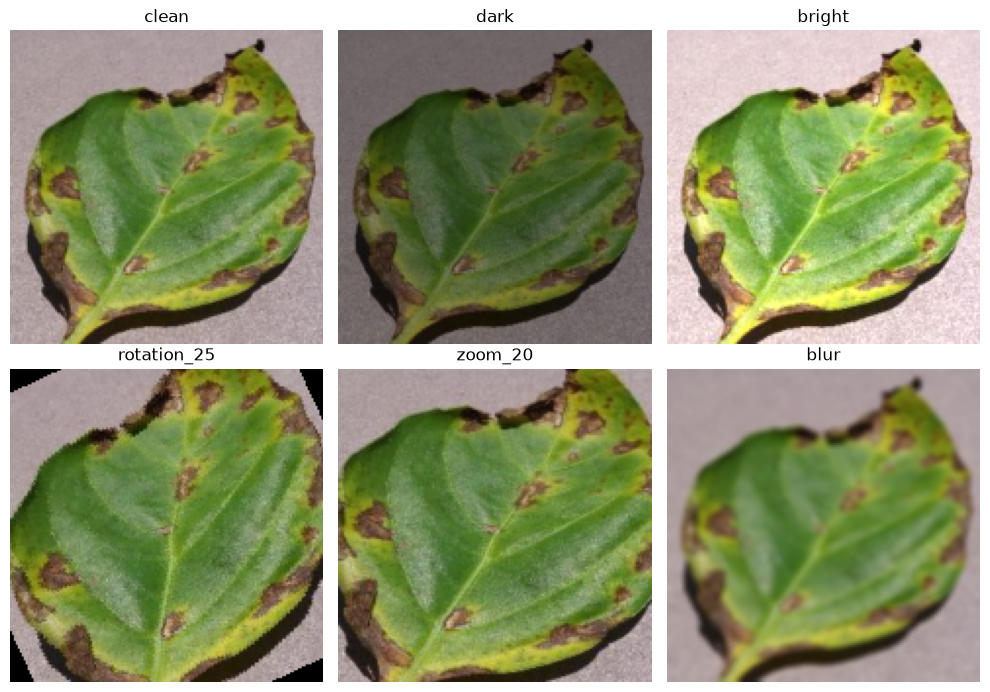

In [4]:
# Ejemplo visual de las perturbaciones
sample = Image.open(DATA_DIR / test_df.iloc[0]["relpath"]).convert("RGB")

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, (name, tf) in zip(axes.ravel(), RAW_PERTURBATIONS.items()):
    ax.imshow(tf(sample))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Evaluación de los checkpoints

In [5]:
EXPERIMENTS = {
    "mnv3s_noaug": ("mobilenet_v3_small", 6, False),
    "mnv3s_aug":   ("mobilenet_v3_small", 6, True),
    "effb0_noaug": ("efficientnet_b0", 3, False),
    "effb0_aug":   ("efficientnet_b0", 3, True),
}

missing = [name for name in EXPERIMENTS if not (CKPT_DIR / f"{name}.pt").exists()]
if missing:
    raise FileNotFoundError(
        f"Faltan checkpoints en {CKPT_DIR}: {missing}. "
        "Ejecutar primero la notebook 03."
    )

rows = []
predictions = {}

for run_name, (model_name, n_unfreeze, used_aug) in EXPERIMENTS.items():
    print(f"\nEvaluando {run_name}")

    net = finetune_model(model_name, len(classes), n_unfreeze)
    state = torch.load(CKPT_DIR / f"{run_name}.pt", map_location=DEVICE)
    net.load_state_dict(state)
    net = net.to(DEVICE).eval()

    for perturb_name, raw_tf in RAW_PERTURBATIONS.items():
        print(f"  - {perturb_name}")

        loader = DataLoader(
            PlantDataset(test_df, transform=model_transform(raw_tf)),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=(DEVICE.type == "cuda"),
        )

        logits, y_true = predict_loader(net, loader)
        y_pred = logits.argmax(1)
        m = metrics(y_true, y_pred)

        predictions[(run_name, perturb_name)] = (y_true, y_pred)

        rows.append({
            "corrida": run_name,
            "modelo": model_name,
            "augmentation": used_aug,
            "perturbacion": perturb_name,
            **m,
        })

rob = pd.DataFrame(rows)
rob.to_csv(OUT_DIR / "robustness.csv", index=False)
rob.head()



Evaluando mnv3s_noaug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur

Evaluando mnv3s_aug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur

Evaluando effb0_noaug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur

Evaluando effb0_aug
  - clean
  - dark
  - bright
  - rotation_25
  - zoom_20
  - blur


,corrida,modelo,augmentation,perturbacion,accuracy,balanced_acc,macro_f1
0,mnv3s_noaug,mobilenet_v3_small,False,clean,0.993218,0.986560,0.986748
1,mnv3s_noaug,mobilenet_v3_small,False,dark,0.968125,0.954915,0.961184
2,mnv3s_noaug,mobilenet_v3_small,False,bright,0.981011,0.978013,0.975117
3,mnv3s_noaug,mobilenet_v3_small,False,rotation_25,0.903357,0.876651,0.883283
4,mnv3s_noaug,mobilenet_v3_small,False,zoom_20,0.969481,0.962686,0.964805


## 3. Resultados

Además del macro-F1 absoluto, se mide cuánto cae cada modelo respecto de su propio resultado sobre test limpio.

In [6]:
PERTURB_ORDER = list(RAW_PERTURBATIONS)

f1_table = (
    rob.pivot(index="perturbacion", columns="corrida", values="macro_f1")
       .reindex(PERTURB_ORDER)
)

f1_table.round(4)


corrida,effb0_aug,effb0_noaug,mnv3s_aug,mnv3s_noaug
perturbacion,,,,
clean,0.9952,0.9928,0.9857,0.9867
dark,0.9922,0.9859,0.9842,0.9612
bright,0.9943,0.9886,0.9821,0.9751
rotation_25,0.9880,0.9072,0.9769,0.8833
zoom_20,0.9921,0.9769,0.9893,0.9648
blur,0.9814,0.7497,0.9806,0.8041


Caída de macro-F1 respecto del test limpio:


corrida,effb0_aug,effb0_noaug,mnv3s_aug,mnv3s_noaug
perturbacion,,,,
clean,0.0000,0.0000,0.0000,0.0000
dark,0.0030,0.0069,0.0014,0.0256
bright,0.0009,0.0042,0.0036,0.0116
rotation_25,0.0072,0.0856,0.0088,0.1035
zoom_20,0.0031,0.0159,-0.0036,0.0219
blur,0.0138,0.2431,0.0051,0.1826


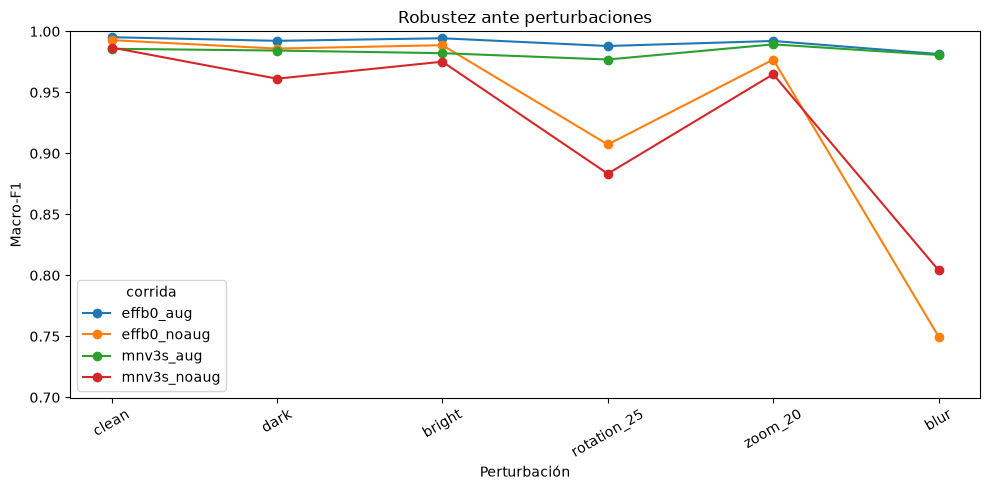

In [7]:
clean = f1_table.loc["clean"]
drop_table = clean - f1_table

print("Caída de macro-F1 respecto del test limpio:")
display(drop_table.round(4))

ax = f1_table.plot(marker="o", figsize=(10, 5))
ax.set_ylabel("Macro-F1")
ax.set_xlabel("Perturbación")
ax.set_ylim(max(0, f1_table.min().min() - 0.05), 1.0)
ax.set_title("Robustez ante perturbaciones")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 4. ¿Ayuda el data augmentation?

Para cada arquitectura se calcula:

**macro-F1 con augmentation − macro-F1 sin augmentation**

Un valor positivo indica que el modelo entrenado con augmentation fue más robusto en esa condición.

In [8]:
aug_gain = pd.DataFrame({
    "MobileNetV3-Small": (
        f1_table["mnv3s_aug"] - f1_table["mnv3s_noaug"]
    ),
    "EfficientNet-B0": (
        f1_table["effb0_aug"] - f1_table["effb0_noaug"]
    ),
})

print("Ganancia de macro-F1 por usar augmentation (positivo = mejora):")
display(aug_gain.round(4))

summary_robustness = pd.DataFrame({
    "macro-F1 clean": f1_table.loc["clean"],
    "macro-F1 promedio perturbado": f1_table.drop(index="clean").mean(),
    "peor macro-F1": f1_table.drop(index="clean").min(),
})

summary_robustness["caída promedio"] = (
    summary_robustness["macro-F1 clean"]
    - summary_robustness["macro-F1 promedio perturbado"]
)

summary_robustness.round(4)


Ganancia de macro-F1 por usar augmentation (positivo = mejora):


,MobileNetV3-Small,EfficientNet-B0
perturbacion,,
clean,-0.0011,0.0024
dark,0.0231,0.0064
bright,0.0070,0.0057
rotation_25,0.0936,0.0807
zoom_20,0.0245,0.0152
blur,0.1765,0.2317


,macro-F1 clean,macro-F1 promedio perturbado,peor macro-F1,caída promedio
corrida,,,,
effb0_aug,0.9952,0.9896,0.9814,0.0056
effb0_noaug,0.9928,0.9217,0.7497,0.0711
mnv3s_aug,0.9857,0.9826,0.9769,0.0031
mnv3s_noaug,0.9867,0.9177,0.8041,0.0690


## 5. Análisis del caso más difícil

Se toma como modelo principal la corrida elegida por **macro-F1 de validación** en el notebook 03 y se analiza la perturbación donde más cae.

In [9]:
summary_path = ROOT / "results" / "finetune_full" / "summary.csv"
summary = pd.read_csv(summary_path, index_col=0)

BEST = summary["val macro-F1"].idxmax()
worst = (
    f1_table[BEST]
    .drop(index="clean")
    .idxmin()
)

print("Modelo elegido por validación:", BEST)
print("Perturbación más difícil:", worst)

y_true, y_pred = predictions[(BEST, worst)]

report = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=range(len(classes)),
        target_names=short,
        output_dict=True,
        zero_division=0,
    )
).T

report.loc[short, ["precision", "recall", "f1-score", "support"]].sort_values("f1-score").round(3)

Modelo elegido por validación: effb0_noaug
Perturbación más difícil: blur


,precision,recall,f1-score,support
Tomato Target Spot,0.973,0.179,0.303,201.0
Tomato Spider mites Two spotted spider mite,1.000,0.218,0.357,239.0
Tomato Early blight,0.325,0.986,0.489,143.0
Tomato Septoria leaf spot,1.000,0.462,0.632,253.0
Tomato Leaf Mold,0.583,0.926,0.716,136.0
Tomato Tomato YellowLeaf Curl Virus,0.577,0.993,0.730,458.0
Tomato Bacterial spot,0.984,0.615,0.757,304.0
Pepper bell Bacterial spot,1.000,0.692,0.818,143.0
Tomato Tomato mosaic virus,0.697,1.000,0.822,53.0
Potato healthy,0.947,0.857,0.900,21.0


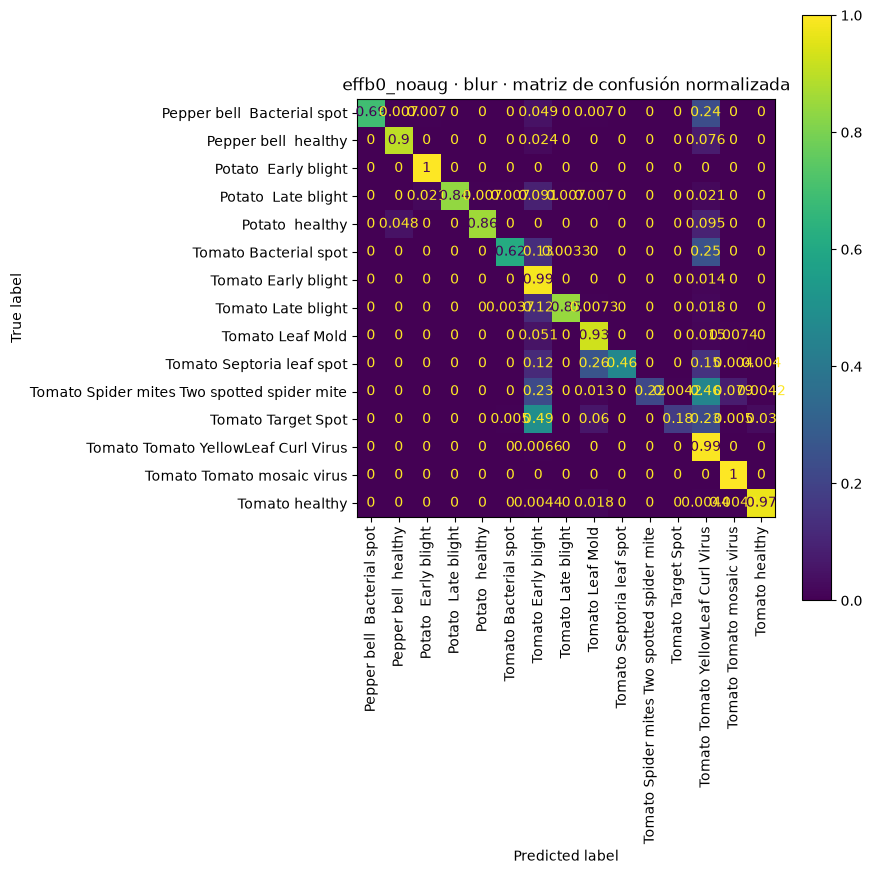

In [10]:
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=short,
    normalize="true",
    xticks_rotation=90,
    ax=ax,
)
ax.set_title(f"{BEST} · {worst} · matriz de confusión normalizada")
plt.tight_layout()
plt.show()

## 6. Evaluación externa con PlantDoc

Además de las perturbaciones sintéticas, se evalúa el comportamiento sobre un pequeño conjunto externo de **PlantDoc**.

Estas imágenes tienen fondos, iluminación y encuadres más variados que PlantVillage. Se usan únicamente como prueba de cambio de dominio; **no participan del entrenamiento ni de la selección del modelo**.

Se consideran seis clases compatibles entre ambos datasets, con 5 imágenes por clase (30 imágenes en total).


In [11]:
import base64
import random
import re
import requests


EXTERNAL_DIR = ROOT / "data" / "real_world"
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

N_PER_CLASS = 5
rng = random.Random(42)

CLASS_MAP = {
    "Potato leaf early blight": "Potato___Early_blight",
    "Potato leaf late blight": "Potato___Late_blight",
    "Tomato Early blight leaf": "Tomato_Early_blight",
    "Tomato Septoria leaf spot": "Tomato_Septoria_leaf_spot",
    "Tomato leaf bacterial spot": "Tomato_Bacterial_spot",
    "Tomato leaf late blight": "Tomato_Late_blight",
}

API_BASE = "https://api.github.com/repos/pratikkayal/PlantDoc-Dataset/contents/test"

VALID_EXT = {".jpg", ".jpeg", ".png"}


def safe_name(name):
    """Elimina caracteres no permitidos por Windows."""
    return re.sub(r'[<>:"/\\|?*]', "_", name)


for source_class, target_class in CLASS_MAP.items():

    target_dir = EXTERNAL_DIR / target_class
    target_dir.mkdir(parents=True, exist_ok=True)

    existing = [
        p for p in target_dir.iterdir()
        if p.suffix.lower() in VALID_EXT
    ]

    needed = N_PER_CLASS - len(existing)

    if needed <= 0:
        print(f"{target_class}: ya tiene {len(existing)} imágenes")
        continue

    # Obtener archivos disponibles de PlantDoc
    response = requests.get(
        f"{API_BASE}/{source_class}",
        params={"ref": "master"},
        timeout=30
    )
    response.raise_for_status()

    files = [
        item for item in response.json()
        if item["type"] == "file"
        and Path(item["name"]).suffix.lower() in VALID_EXT
        and item.get("git_url")
    ]

    rng.shuffle(files)

    downloaded = 0

    for item in files:

        if downloaded >= needed:
            break

        try:
            # Descarga el blob directamente desde la API de GitHub.
            blob_response = requests.get(
                item["git_url"],
                timeout=30
            )
            blob_response.raise_for_status()

            blob = blob_response.json()

            image_bytes = base64.b64decode(
                blob["content"].replace("\n", "")
            )

            filename = (
                f"{len(existing) + downloaded + 1:02d}_"
                f"{safe_name(item['name'])}"
            )

            destination = target_dir / filename
            destination.write_bytes(image_bytes)

            downloaded += 1

        except Exception as e:
            print(f"  Se omite {item['name']}: {e}")

    total = len([
        p for p in target_dir.iterdir()
        if p.suffix.lower() in VALID_EXT
    ])

    print(f"{target_class}: {total} imágenes")

Potato___Early_blight: ya tiene 5 imágenes
Potato___Late_blight: ya tiene 5 imágenes
Tomato_Early_blight: ya tiene 5 imágenes
Tomato_Septoria_leaf_spot: ya tiene 5 imágenes
Tomato_Bacterial_spot: ya tiene 5 imágenes
Tomato_Late_blight: ya tiene 5 imágenes


In [12]:
EXTERNAL_DIR = ROOT / "data" / "real_world"

EXTERNAL_CLASSES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Septoria_leaf_spot",
]

valid_ext = {".jpg", ".jpeg", ".png"}
class_to_idx = {name: i for i, name in enumerate(classes)}

samples = []

for class_name in EXTERNAL_CLASSES:
    folder = EXTERNAL_DIR / class_name

    if not folder.exists():
        raise FileNotFoundError(
            f"No existe {folder}. "
            "Primero descargar las imágenes externas de PlantDoc."
        )

    if class_name not in class_to_idx:
        raise ValueError(
            f"La clase {class_name} no existe en class_to_idx.json"
        )

    images = [
        p for p in sorted(folder.iterdir())
        if p.suffix.lower() in valid_ext
    ]

    print(f"{class_name}: {len(images)} imágenes")

    for path in images:
        samples.append({
            "path": path,
            "true_class": class_name,
            "y": class_to_idx[class_name],
        })

external_df = pd.DataFrame(samples)

print(f"\nImágenes externas totales: {len(external_df)}")

display(
    external_df["true_class"]
    .value_counts()
    .sort_index()
)

Potato___Early_blight: 5 imágenes
Potato___Late_blight: 5 imágenes
Tomato_Bacterial_spot: 5 imágenes
Tomato_Early_blight: 5 imágenes
Tomato_Late_blight: 5 imágenes
Tomato_Septoria_leaf_spot: 5 imágenes

Imágenes externas totales: 30


true_class
Potato___Early_blight        5
Potato___Late_blight         5
Tomato_Bacterial_spot        5
Tomato_Early_blight          5
Tomato_Late_blight           5
Tomato_Septoria_leaf_spot    5
Name: count, dtype: int64

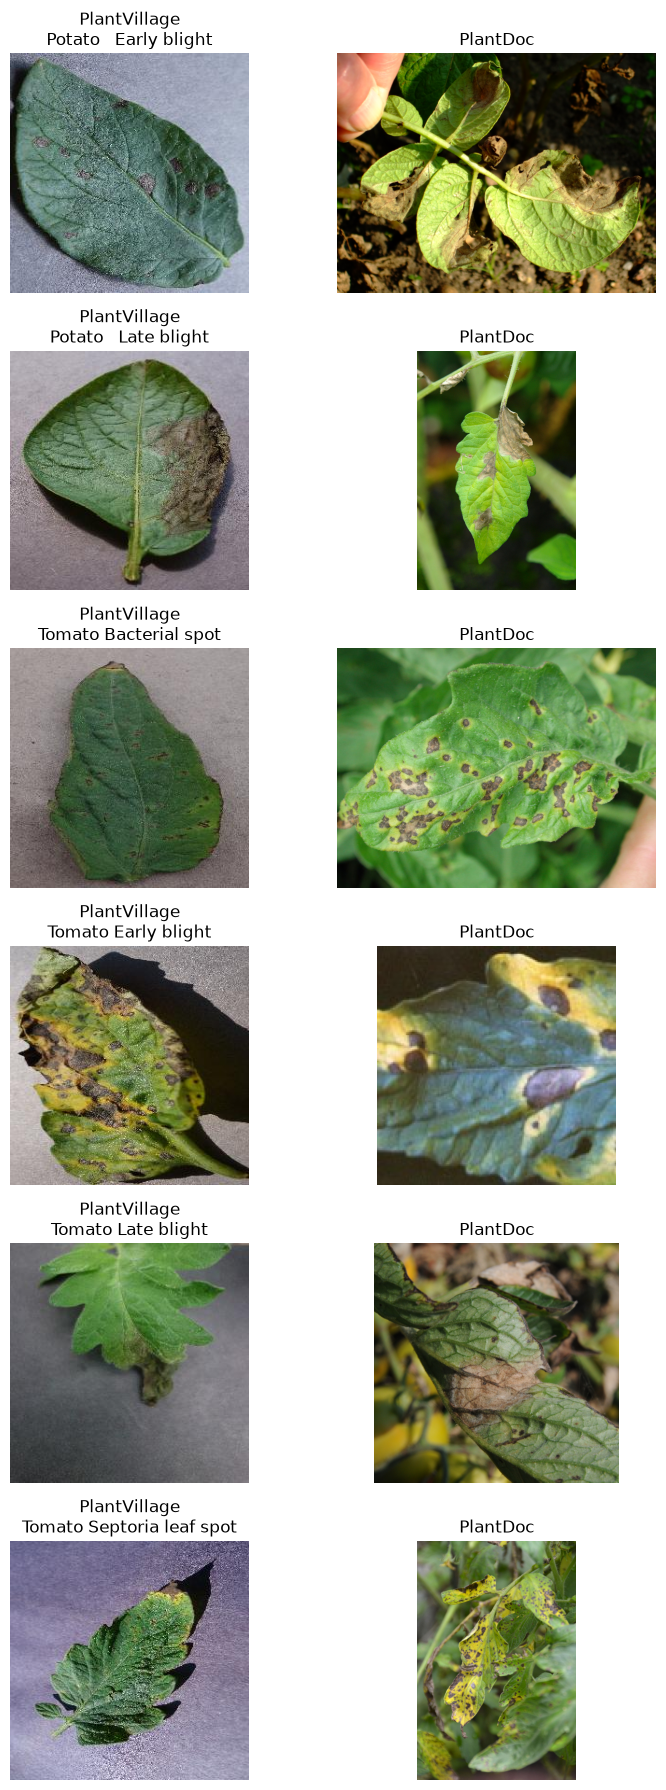

In [13]:
fig, axes = plt.subplots(len(EXTERNAL_CLASSES), 2, figsize=(8, 18))

class_to_idx = {name: i for i, name in enumerate(classes)}

for i, class_name in enumerate(EXTERNAL_CLASSES):

    # -------------------------
    # PlantVillage
    # -------------------------
    class_idx = class_to_idx[class_name]

    pv_row = test_df[
        test_df["y"] == class_idx
    ].iloc[0]

    pv_img = Image.open(
        DATA_DIR / pv_row["relpath"]
    ).convert("RGB")

    # -------------------------
    # PlantDoc
    # -------------------------
    ext_row = external_df[
        external_df["true_class"] == class_name
    ].iloc[0]

    ext_img = Image.open(
        ext_row["path"]
    ).convert("RGB")

    # -------------------------
    # Mostrar
    # -------------------------
    axes[i, 0].imshow(pv_img)
    axes[i, 0].set_title(
        f"PlantVillage\n{class_name.replace('_', ' ')}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(ext_img)
    axes[i, 1].set_title("PlantDoc")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [14]:
class ExternalDataset(Dataset):
    def __init__(self, data, transform):
        self.data = data.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        row = self.data.iloc[i]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img), int(row["y"])


_, external_tf = make_transforms(IMG_SIZE_FT, augment=False)

external_loader = DataLoader(
    ExternalDataset(external_df, external_tf),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)


### Comparación con y sin data augmentation

Para mantener la prueba simple, se comparan las dos versiones de **EfficientNet-B0**. El objetivo es observar si el augmentation ayuda frente al cambio de dominio.


In [15]:
external_rows = []
external_predictions = []

external_label_ids = [class_to_idx[c] for c in EXTERNAL_CLASSES]

for run_name in ["effb0_noaug", "effb0_aug"]:
    model_name, n_unfreeze, used_aug = EXPERIMENTS[run_name]

    net = finetune_model(model_name, len(classes), n_unfreeze)
    state = torch.load(CKPT_DIR / f"{run_name}.pt", map_location=DEVICE)
    net.load_state_dict(state)
    net = net.to(DEVICE).eval()

    logits, y_true = predict_loader(net, external_loader)
    y_pred = logits.argmax(1)
    probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()

    external_rows.append({
        "corrida": run_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "macro_f1_6_clases": f1_score(
            y_true,
            y_pred,
            labels=external_label_ids,
            average="macro",
            zero_division=0,
        ),
    })

    for i, row in external_df.reset_index(drop=True).iterrows():
        external_predictions.append({
            "corrida": run_name,
            "archivo": Path(row["path"]).name,
            "clase_real": classes[y_true[i]],
            "prediccion": classes[y_pred[i]],
            "confianza": float(probs[i, y_pred[i]]),
            "correcta": bool(y_true[i] == y_pred[i]),
        })

external_results = pd.DataFrame(external_rows).set_index("corrida")
external_predictions = pd.DataFrame(external_predictions)

external_results.to_csv(OUT_DIR / "plantdoc_external_metrics.csv")
external_predictions.to_csv(OUT_DIR / "plantdoc_external_predictions.csv", index=False)

display(external_results.round(4))


c:\Users\tolot\anaconda3\envs\vpc2\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\tolot\anaconda3\envs\vpc2\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,accuracy,balanced_acc,macro_f1_6_clases
corrida,,,
effb0_noaug,0.2333,0.2333,0.1778
effb0_aug,0.2667,0.2667,0.1673


In [16]:
# Errores de la evaluación externa
errors = (
    external_predictions[~external_predictions["correcta"]]
    .sort_values(["corrida", "confianza"], ascending=[True, False])
)

print(f"Errores totales: {len(errors)}")
display(errors)


Errores totales: 45


,corrida,archivo,clase_real,prediccion,confianza,correcta
43,effb0_aug,04_Tom_Bact3.jpg,Tomato_Bacterial_spot,Tomato_Late_blight,0.995995,False
31,effb0_aug,02_3023.jpg,Potato___Early_blight,Tomato_Early_blight,0.994974,False
30,effb0_aug,01_backus-056-potato-blight.jpg,Potato___Early_blight,Tomato_Early_blight,0.992156,False
35,effb0_aug,01_5816740026_d42ef24413_Phytophthora-Infestan...,Potato___Late_blight,Tomato_Late_blight,0.991138,False
36,effb0_aug,02_20090710-lateblight.jpg,Potato___Late_blight,Tomato_Late_blight,0.971223,False
51,effb0_aug,02_70.jpg,Tomato_Late_blight,Tomato_Early_blight,0.965693,False
56,effb0_aug,02_RARZ4.jpg,Tomato_Septoria_leaf_spot,Tomato_Early_blight,0.961063,False
59,effb0_aug,05_636227737977191231-septoria-leaf-spot-VT.jpg,Tomato_Septoria_leaf_spot,Tomato_Early_blight,0.956022,False
58,effb0_aug,04_sept4disease-019.jpg,Tomato_Septoria_leaf_spot,Tomato_Early_blight,0.894017,False
41,effb0_aug,02_bact-spot-fig-1.jpg,Tomato_Bacterial_spot,Pepper__bell___Bacterial_spot,0.867917,False


## 7. Conclusión

Con esta notebook se analizan cuatro aspectos:

1. Qué perturbaciones afectan más a cada modelo.
2. Qué arquitectura conserva mejor su desempeño frente a cambios visuales.
3. Si el data augmentation mejora la robustez aunque no mejore el test limpio.
4. Cómo se comporta EfficientNet-B0 sobre imágenes externas de PlantDoc, con un cambio de dominio más cercano a condiciones reales.

La evaluación externa es exploratoria y no se utiliza para seleccionar el modelo.

Los resultados se guardan en:

- `results/robustness/robustness.csv`
- `results/robustness/plantdoc_external_metrics.csv`
- `results/robustness/plantdoc_external_predictions.csv`
